# InternNova — Data Analytics Internship
## Week 4 Assignment: Statistics, Data Visualization & Exploratory Data Analysis 
**Dataset:** `sales_data.csv` \
**Prepared by:** Brojo Mohan Dutta\
**Environment:** Anaconda / Jupyter Notebook 7.4.5 / Python 3.x / Pandas

# Setup & Load Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sales_data.csv")
df.head()

,order_id,order_date,product_category,region,units_sold,unit_price,customer_age,customer_rating,payment_method,revenue
0,1001,2024-01-01,Books,West,9,774.05,29,4.7,UPI,6966.45
1,1002,2024-01-04,Sports,East,12,3623.57,56,1.6,Cash on Delivery,43482.84
2,1003,2024-01-07,Home & Kitchen,West,12,3851.77,19,2.4,Debit Card,46221.24
3,1004,2024-01-10,Sports,East,12,2894.13,20,1.5,Debit Card,34729.56
4,1005,2024-01-13,Sports,West,13,3900.64,54,4.7,UPI,50708.32


# Task 1: Mean, Median & Mode

#### Explanation: 
Calculates the three central-tendency measures on revenue (mean/median) and units_sold (mode). Mean shows the average order value but is pulled upward by the outlier order; median is more robust to that outlier and better represents a "typical" order; mode shows the most commonly ordered quantity.

In [6]:
mean_revenue = df["revenue"].mean()
median_revenue = df["revenue"].median()
mode_units_sold = df["units_sold"].mode()[0]

print("Mean Revenue:", round(mean_revenue, 2))
print("Median Revenue:", round(median_revenue, 2))
print("Mode of Units Sold:", mode_units_sold)

Mean Revenue: 25706.56
Median Revenue: 16448.25
Mode of Units Sold: 12


#### Explanation of results: 
Mean revenue (₹25,706.56) is much higher than the median (₹16,448.25) — a clear sign of a right-skewed distribution pulled by the outlier order (120 units).\
Mode of units_sold (12) shows that ordering 12 units is the most frequent order size.

# Task 2: Variance & Standard Deviation

#### Explanation: 
Computes variance and standard deviation of revenue to quantify how spread out order values are around the mean.

In [7]:
variance_revenue = df["revenue"].var()
std_revenue = df["revenue"].std()

print("Variance of Revenue:", round(variance_revenue, 2))
print("Standard Deviation of Revenue:", round(std_revenue, 2))

Variance of Revenue: 1444248098.37
Standard Deviation of Revenue: 38003.26


#### Explanation of results: 
A standard deviation of ~₹38,003 (larger than the median itself) indicates high variability in order values — driven mainly by the single 120-unit outlier order, confirming that revenue is not tightly clustered around the average.

# Task 3: Correlation & Probability Basics

#### Explanation: 
Correlation checks the linear relationship between unit_price and revenue, and separately between customer_age and customer_rating. The probability example calculates the real-world chance a random order was paid via Credit Card.

In [8]:
# Correlation
corr_price_revenue = df["unit_price"].corr(df["revenue"])
corr_age_rating = df["customer_age"].corr(df["customer_rating"])

print("Correlation (unit_price vs revenue):", round(corr_price_revenue, 3))
print("Correlation (customer_age vs customer_rating):", round(corr_age_rating, 3))

# Probability example: chance an order was paid by Credit Card
total_orders = len(df)
credit_card_orders = len(df[df["payment_method"] == "Credit Card"])
probability_credit_card = credit_card_orders / total_orders

print(f"P(Payment Method = Credit Card) = {credit_card_orders}/{total_orders} = {round(probability_credit_card, 3)}")

Correlation (unit_price vs revenue): 0.245
Correlation (customer_age vs customer_rating): -0.279
P(Payment Method = Credit Card) = 18/52 = 0.346


#### Explanation of results: 
unit_price vs revenue shows a weak positive correlation (0.245) — expected, since revenue also depends on units_sold, not price alone. customer_age vs customer_rating shows a weak negative correlation (-0.279), suggesting a slight tendency for older customers to give marginally lower ratings, though the relationship is not strong. Probability of a Credit Card payment is 34.6% (18 of 52 orders).

# Task 4: Outlier Detection

#### Explanation: 
Uses the IQR (Interquartile Range) method on units_sold — values beyond Q1 - 1.5×IQR or Q3 + 1.5×IQR are flagged as outliers.

In [9]:
Q1 = df["units_sold"].quantile(0.25)
Q3 = df["units_sold"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["units_sold"] < lower_bound) | (df["units_sold"] > upper_bound)]

print("Q1:", Q1, "| Q3:", Q3, "| IQR:", IQR)
print("Lower Bound:", lower_bound, "| Upper Bound:", upper_bound)
print("Outliers detected:\n", outliers[["order_id", "units_sold", "revenue"]])

Q1: 4.5 | Q3: 11.25 | IQR: 6.75
Lower Bound: -5.625 | Upper Bound: 21.375
Outliers detected:
     order_id  units_sold   revenue
40      1041         120  264428.4


#### Explanation of results: 
With Q1=4.5, Q3=11.25, and an upper bound of 21.375, order 1041 (units_sold = 120) is flagged as a clear outlier — over 5x the upper bound. Outliers like this can distort the mean, inflate variance/std deviation, and mislead trend analysis if not handled — they should be investigated (data entry error vs. genuine bulk order) before deciding to cap, remove, or keep them.

# Prep for Visualization

#### Explanation: 
Converts order_date to a proper datetime type so the line chart plots chronologically.

In [10]:
df["order_date"] = pd.to_datetime(df["order_date"])
# Group total revenue by order date
daily_revenue = (df.groupby("order_date")["revenue"].sum().reset_index())
# Sort by date
daily_revenue = daily_revenue.sort_values("order_date")

# Task 5: Matplotlib Visualization

#### Explanation: 
Five Matplotlib charts, each on a different variable pair, to explore the sales data from different angles.

## 1. Line Chart — Revenue trend over time

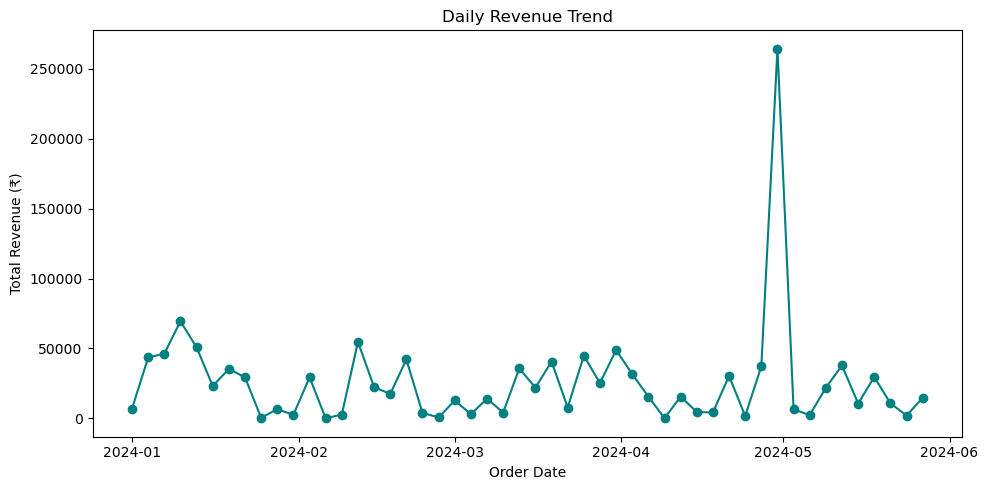

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(daily_revenue["order_date"],daily_revenue["revenue"],marker="o", color="teal")
plt.title("Daily Revenue Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Revenue (₹)")
plt.tight_layout()
plt.show()

#### Explanation: 
Tracks order-by-order revenue chronologically. A single sharp spike stands out around late April — the 120-unit outlier order — otherwise revenue fluctuates in a normal ₹1,000–₹55,000 band.

## 2. Bar Chart — Total revenue by category

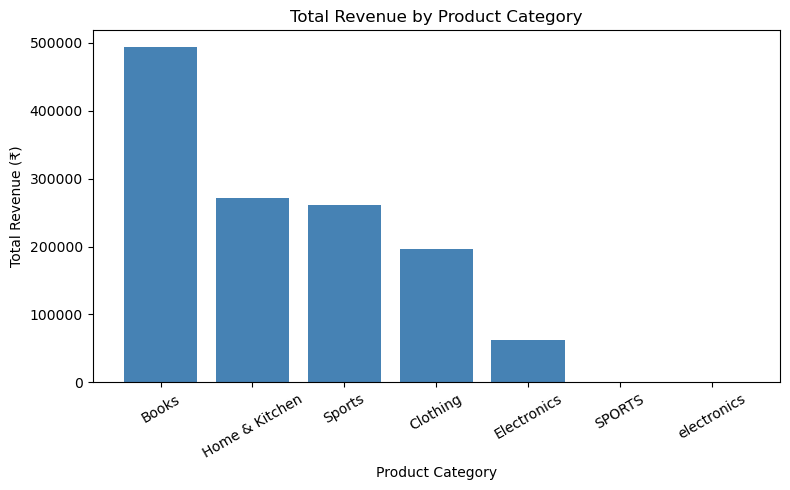

In [12]:
cat_revenue = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(cat_revenue.index, cat_revenue.values, color="steelblue")
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Explanation: 
Books leads total revenue (₹493,782) — largely inflated by the outlier order — followed by Home & Kitchen and Sports. Note "electronics" and "SPORTS" appear as separate tiny bars here because casing hasn't been cleaned yet — this issue gets fixed in Task 7.

## 3. Pie Chart — Share of orders by region

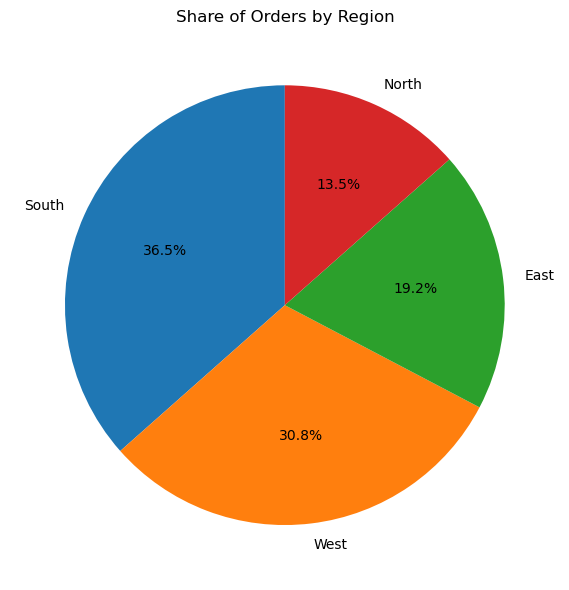

In [13]:
region_orders = df["region"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(region_orders.values, labels=region_orders.index, autopct="%1.1f%%", startangle=90)
plt.title("Share of Orders by Region")
plt.tight_layout()
plt.show()

#### Explanation: 
South dominates order share (36.5%), followed by West (30.8%); North has the smallest share (13.5%) — useful for spotting regional demand concentration.

## 4. Histogram — Customer age distribution

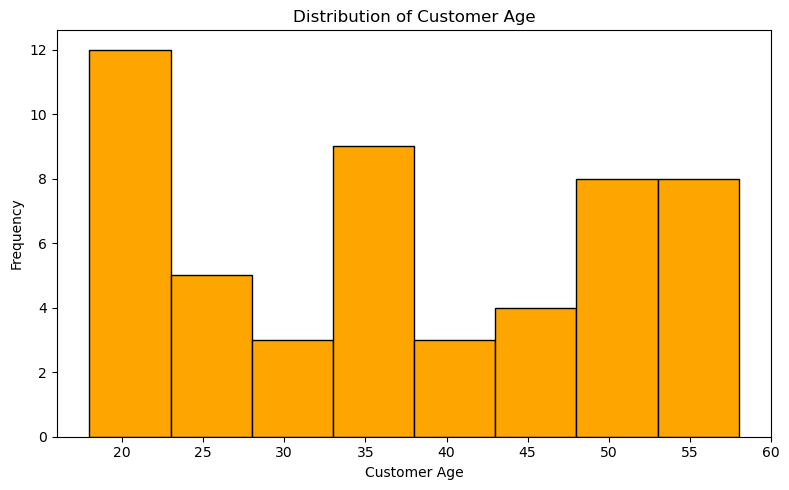

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["customer_age"], bins=8, color="orange", edgecolor="black")
plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Explanation: 
Shows the frequency of customers across age bands, revealing whether the customer base skews toward a particular generation — helpful for targeted marketing.

## 5. Scatter Plot — Units sold vs revenue

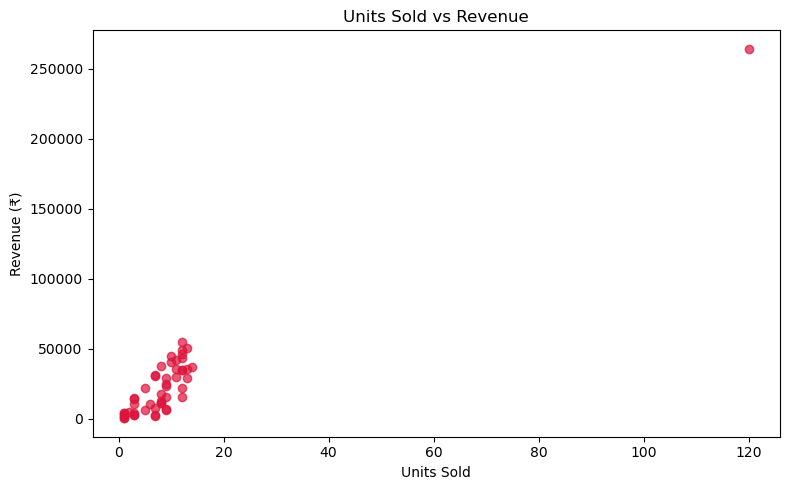

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df["units_sold"], df["revenue"], color="crimson", alpha=0.7)
plt.title("Units Sold vs Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.show()

#### Explanation: 
Strong positive relationship between units sold and revenue (confirmed numerically in Task 8, corr ≈ 0.96) — expected, since revenue is directly derived from units × price. The outlier order (120 units) sits far to the right, isolated from the main cluster.

# Task 6: Seaborn Visualization

#### Explanation: 
Four Seaborn plots that add statistical and relational depth beyond what Matplotlib easily shows.

## 1. Count Plot — Orders per category

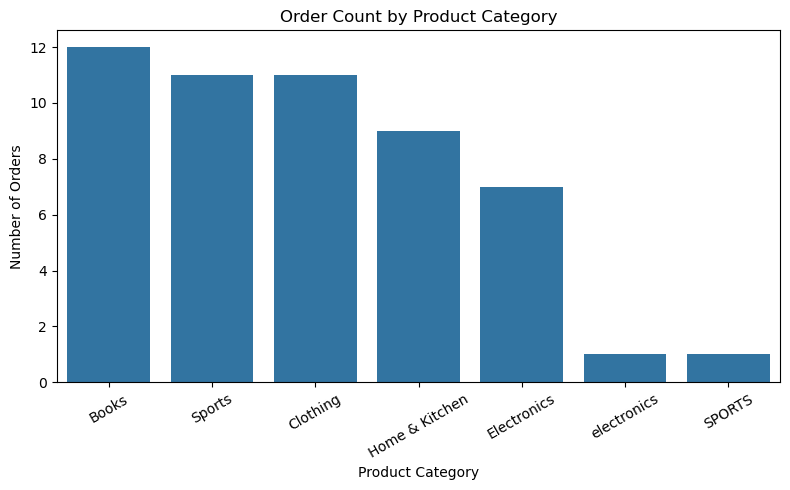

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="product_category", order=df["product_category"].value_counts().index)
plt.title("Order Count by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Explanation: 
Counts orders per category label as-is (pre-cleaning), so Sports, SPORTS, and electronics/Electronics show as separate bars — visually flags the inconsistent-text problem tackled in Task 7.

## 2. Box Plot — Revenue spread by category

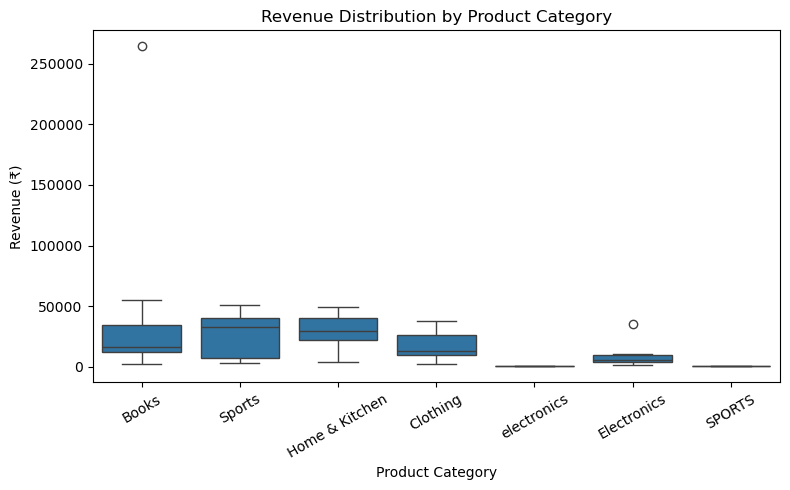

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="product_category", y="revenue")
plt.title("Revenue Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Explanation: 
Shows the median, IQR, and spread of revenue per category. Books shows a clear high outlier point far above its box — the same 120-unit order flagged earlier — visually confirming the Task 4 outlier detection.

## 3. Heatmap — Correlation between numeric variables

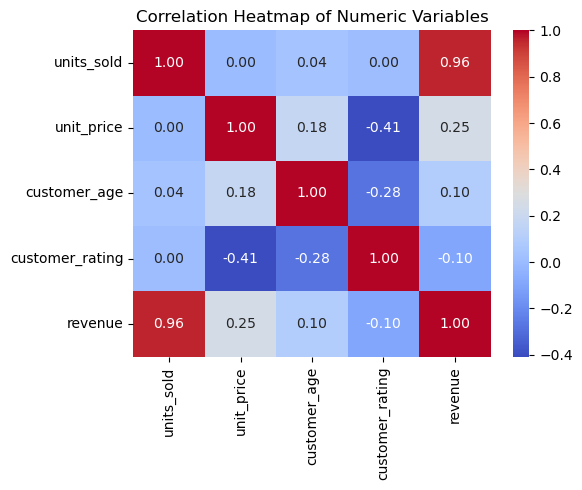

In [18]:
numeric_df = df[["units_sold", "unit_price", "customer_age", "customer_rating", "revenue"]]

plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

#### Explanation: 
units_sold and revenue show the strongest correlation (0.96), as expected. unit_price and customer_rating show a moderate negative correlation (-0.41) — pricier items trending toward slightly lower ratings in this sample. All other pairs are weakly correlated.

## 4. Pair Plot — Pairwise relationships

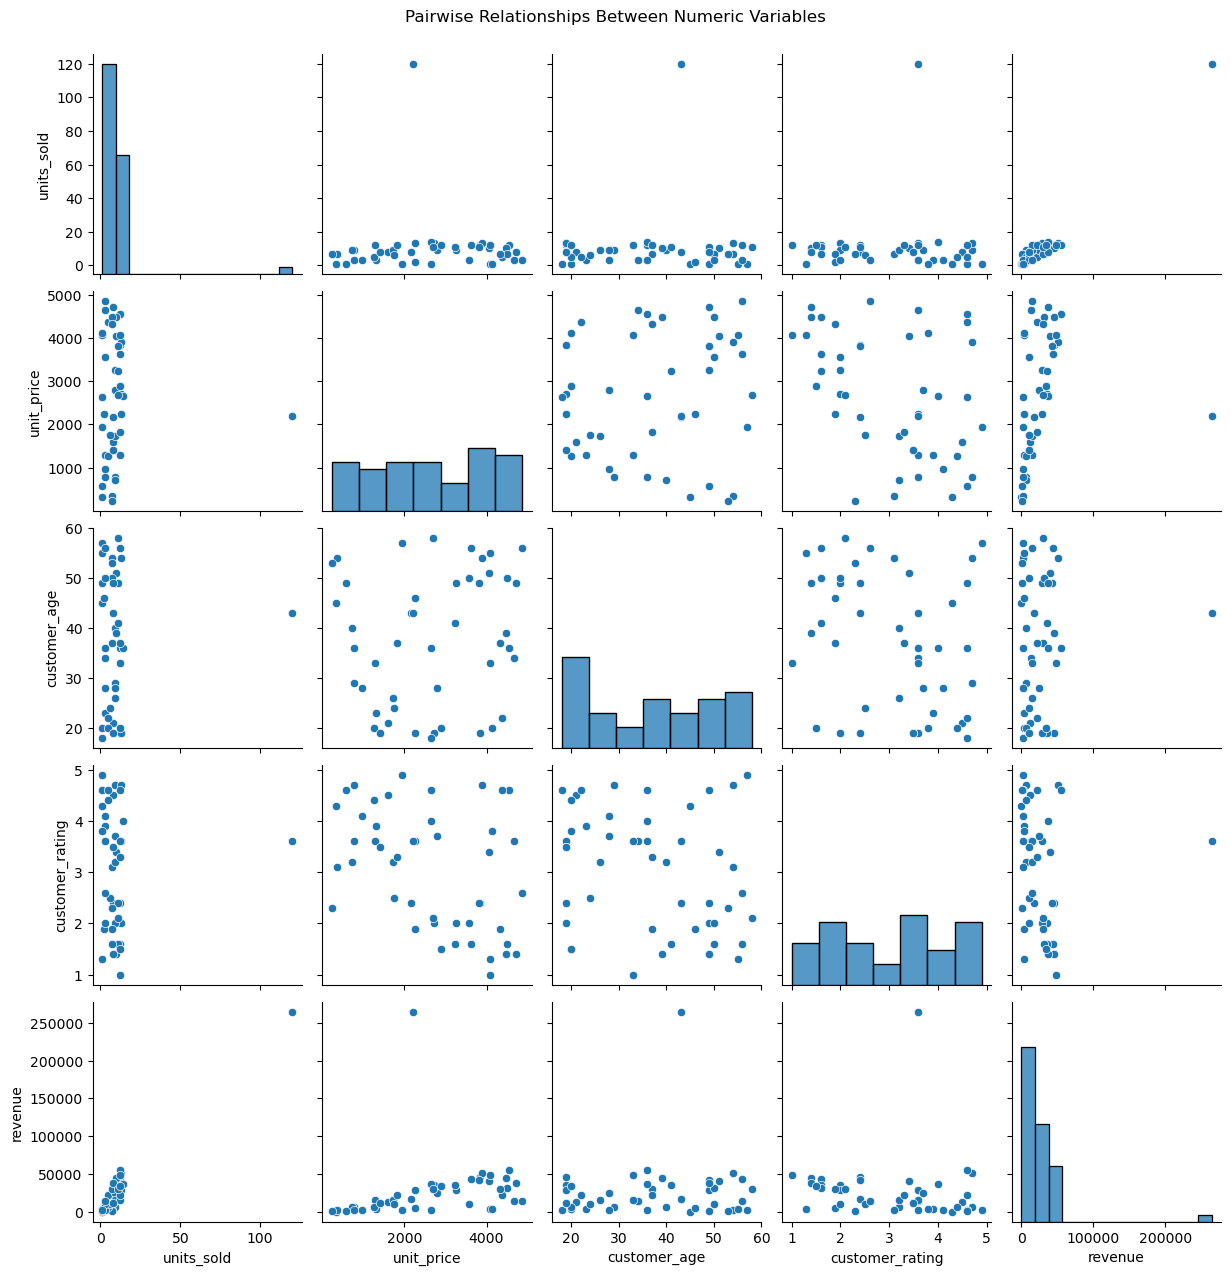

In [19]:
g = sns.pairplot(numeric_df.dropna())
g.fig.suptitle("Pairwise Relationships Between Numeric Variables", y=1.02)
plt.show()

#### Explanation: 
Lays out every numeric variable against every other, with distributions on the diagonal. The units_sold vs revenue panel clearly shows the tight positive linear relationship (and the one outlier point breaking away from the cluster), while other variable pairs show scattered, weak relationships.

# Task 7: EDA – Data Inspection & Cleaning

#### Explanation: 
Full inspection pass followed by a cleaning pass — fixing inconsistent category text, imputing missing values, and dropping duplicates.

## Data Inspection

In [20]:
print("Shape (rows, columns):", df.shape)
print("Column Names:", df.columns.tolist())
print("Data Types:\n", df.dtypes)
print("Statistical Summary:\n", df.describe())

Shape (rows, columns): (52, 10)
Column Names: ['order_id', 'order_date', 'product_category', 'region', 'units_sold', 'unit_price', 'customer_age', 'customer_rating', 'payment_method', 'revenue']
Data Types:
 order_id                     int64
order_date          datetime64[ns]
product_category            object
region                      object
units_sold                   int64
unit_price                 float64
customer_age                 int64
customer_rating            float64
payment_method              object
revenue                    float64
dtype: object
Statistical Summary:
           order_id                     order_date  units_sold   unit_price  \
count    52.000000                             52   52.000000    50.000000   
mean   1024.903846  2024-03-12 17:04:36.923076864    9.788462  2602.683400   
min    1001.000000            2024-01-01 00:00:00    1.000000   233.370000   
25%    1012.750000            2024-02-05 06:00:00    4.500000  1396.600000   
50%    1024.5000

#### Before-cleaning output (key figures): 
Shape (52, 10). unit_price, customer_rating, revenue each have 2 missing values (48/50 non-null out of 52).

## Data Cleaning

In [21]:
# 1. Identify missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# 2. Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# 3. Check inconsistent category text
print("Unique product_category values (raw):", df["product_category"].unique())

# --- Clean ---
df_clean = df.copy()

# Fix inconsistent text (electronics/SPORTS -> Title Case)
df_clean["product_category"] = df_clean["product_category"].str.strip().str.title()

# Handle missing values: median imputation for price/rating, recompute revenue
df_clean["customer_rating"] = df_clean["customer_rating"].fillna(df_clean["customer_rating"].median())
df_clean["unit_price"] = df_clean["unit_price"].fillna(df_clean["unit_price"].median())
df_clean["revenue"] = df_clean["units_sold"] * df_clean["unit_price"]

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print("Unique product_category values (cleaned):", df_clean["product_category"].unique())
print("Missing values after cleaning:\n", df_clean.isnull().sum())
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())
print("Shape after cleaning:", df_clean.shape)

df_clean.to_csv("sales_data_cleaned.csv", index=False)

Missing values before cleaning:
 order_id            0
order_date          0
product_category    0
region              0
units_sold          0
unit_price          2
customer_age        0
customer_rating     2
payment_method      0
revenue             2
dtype: int64
Duplicate rows: 2
Unique product_category values (raw): ['Books' 'Sports' 'Home & Kitchen' 'Clothing' 'electronics' 'Electronics'
 'SPORTS']
Unique product_category values (cleaned): ['Books' 'Sports' 'Home & Kitchen' 'Clothing' 'Electronics']
Missing values after cleaning:
 order_id            0
order_date          0
product_category    0
region              0
units_sold          0
unit_price          0
customer_age        0
customer_rating     0
payment_method      0
revenue             0
dtype: int64
Duplicate rows after cleaning: 0
Shape after cleaning: (50, 10)


#### Before vs After:
| Check | Before | After |
|------|------------|--------|
| Shape | (52, 10) | (50, 10) |
| Missing values | 2 each in unit_price, customer_rating, revenue | 0 |
| Duplicate rows | 2 | 0 |
| Unique category labels | 7 (Sports, SPORTS, Electronics, electronics, ...) | 5 (clean) |

# Task 8: EDA – Correlation & Insights

#### Explanation: 
Re-runs correlation on the cleaned data and aggregates revenue/rating by category, region, and payment method to surface patterns.

Correlation matrix:
                  units_sold  unit_price  customer_age  customer_rating  \
units_sold         1.000000   -0.000671      0.042585         0.008520   
unit_price        -0.000671    1.000000      0.162361        -0.396142   
customer_age       0.042585    0.162361      1.000000        -0.320092   
customer_rating    0.008520   -0.396142     -0.320092         1.000000   
revenue            0.960296    0.239685      0.093548        -0.088483   

                  revenue  
units_sold       0.960296  
unit_price       0.239685  
customer_age     0.093548  
customer_rating -0.088483  
revenue          1.000000  
Revenue by category:
 product_category
Books             493781.60
Home & Kitchen    271066.75
Sports            247681.07
Clothing          185655.31
Electronics        83582.75
Name: revenue, dtype: float64
Revenue by region:
 region
South    565977.63
West     385363.15
East     202871.51
North    127555.19
Name: revenue, dtype: float64
Payment method share (%)

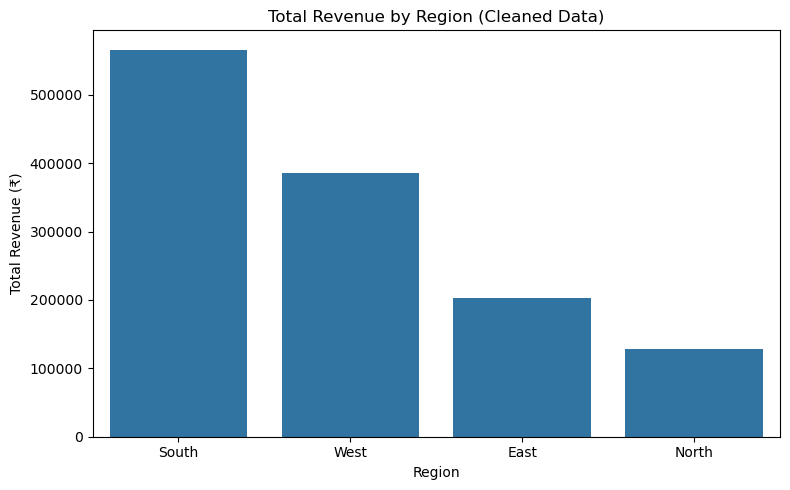

In [22]:
numeric_df = df_clean[["units_sold", "unit_price", "customer_age", "customer_rating", "revenue"]]
print("Correlation matrix:\n", numeric_df.corr())

revenue_by_category = df_clean.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
print("Revenue by category:\n", revenue_by_category)

revenue_by_region = df_clean.groupby("region")["revenue"].sum().sort_values(ascending=False)
print("Revenue by region:\n", revenue_by_region)

payment_share = df_clean["payment_method"].value_counts(normalize=True) * 100
print("Payment method share (%):\n", payment_share)

rating_by_category = df_clean.groupby("product_category")["customer_rating"].mean().sort_values()
print("Average rating by category:\n", rating_by_category)

# supporting visualization
plt.figure(figsize=(8,5))
sns.barplot(x=revenue_by_region.index, y=revenue_by_region.values)
plt.title("Total Revenue by Region (Cleaned Data)")
plt.xlabel("Region")
plt.ylabel("Total Revenue (₹)")
plt.tight_layout()
plt.show()

### Key Insights

#### Insight 1 — Units Sold Has a Strong Relationship with Revenue
units_sold and revenue are strongly correlated (0.96) — revenue is driven almost entirely by order volume rather than unit price (unit_price vs revenue correlation is a weak 0.24), meaning bulk orders matter more to revenue than premium pricing.

---

#### Insight 2 — South Region Generates the Highest Revenue

South region dominates revenue (₹565,978 — 39% of total across 4 regions), nearly 3x North's contribution (₹127,555), showing heavy geographic revenue concentration.

This indicates that customer demand and sales performance are strongest in the South and West regions.

---

#### Insight 3 — Sports Category Has Low Customer Satisfaction

Sports has the lowest average customer rating (2.66) while Clothing has the highest (3.48) — despite Sports being a solid revenue contributor, satisfaction there lags noticeably behind other categories, and unit_price vs customer_rating shows a moderate negative correlation (-0.40), suggesting pricier items tend to get rated lower.

---

# Task 9: Business Recommendations

## Recommendation 1 — Investigate and Address Sports Category Satisfaction

The **Sports** category has the lowest average customer rating (**2.66**) despite being the **3rd highest revenue category (₹247,681)**. Combined with the negative correlation between **Price and Rating (-0.40)**, this suggests that customers may perceive Sports products as overpriced relative to their quality or value.

**Recommended Action:**

- Review Sports product pricing strategies.
- Analyze customer feedback and reviews for quality-related issues.
- Identify products with high prices but low ratings.
- Improve quality control where necessary.
- Avoid applying the same strategy uniformly across all product categories.

> **Business Impact:** Improving customer satisfaction in the Sports category could help maintain its strong revenue contribution while improving customer retention and ratings.

---

## Recommendation 2 — Concentrate Marketing Spend and Inventory on South and West Regions

The **South region (₹565,978)** and **West region (₹385,363)** together generate approximately **66% of total revenue** across the four regions. In comparison, the **North region (₹127,555)** generates significantly lower revenue.

**Recommended Action:**

- Prioritize inventory availability in the South and West regions.
- Increase targeted regional marketing campaigns in these high-performing regions.
- Improve delivery capacity and customer service infrastructure where demand is strongest.
- Conduct a smaller-scale test campaign in the North region before committing a larger marketing budget.
- Analyze whether North's lower performance is caused by lower customer demand or limited marketing reach.

> **Business Impact:** Allocating resources toward proven high-performing regions can improve revenue efficiency, while controlled testing in North can identify growth opportunities without unnecessary budget risk.